In [2]:
# ============================================
# CELLULE 1 — Vérification du fichier
# ============================================
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv


In [3]:
# ============================================
# CELLULE 2 — Chargement des données
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le dataset (chemin complet)
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv')

# Afficher les 5 premières lignes
print("✅ Dataset chargé avec succès !")
print(f"📐 Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print("\n--- Aperçu des données ---")
df.head()

✅ Dataset chargé avec succès !
📐 Dimensions : 768 lignes x 9 colonnes

--- Aperçu des données ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# ============================================
# CELLULE 3 — Exploration des données (EDA)
# ============================================

print("=" * 50)
print("📋 INFORMATIONS GÉNÉRALES")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("📊 STATISTIQUES DESCRIPTIVES")
print("=" * 50)
df.describe()

📋 INFORMATIONS GÉNÉRALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

📊 STATISTIQUES DESCRIPTIVES


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


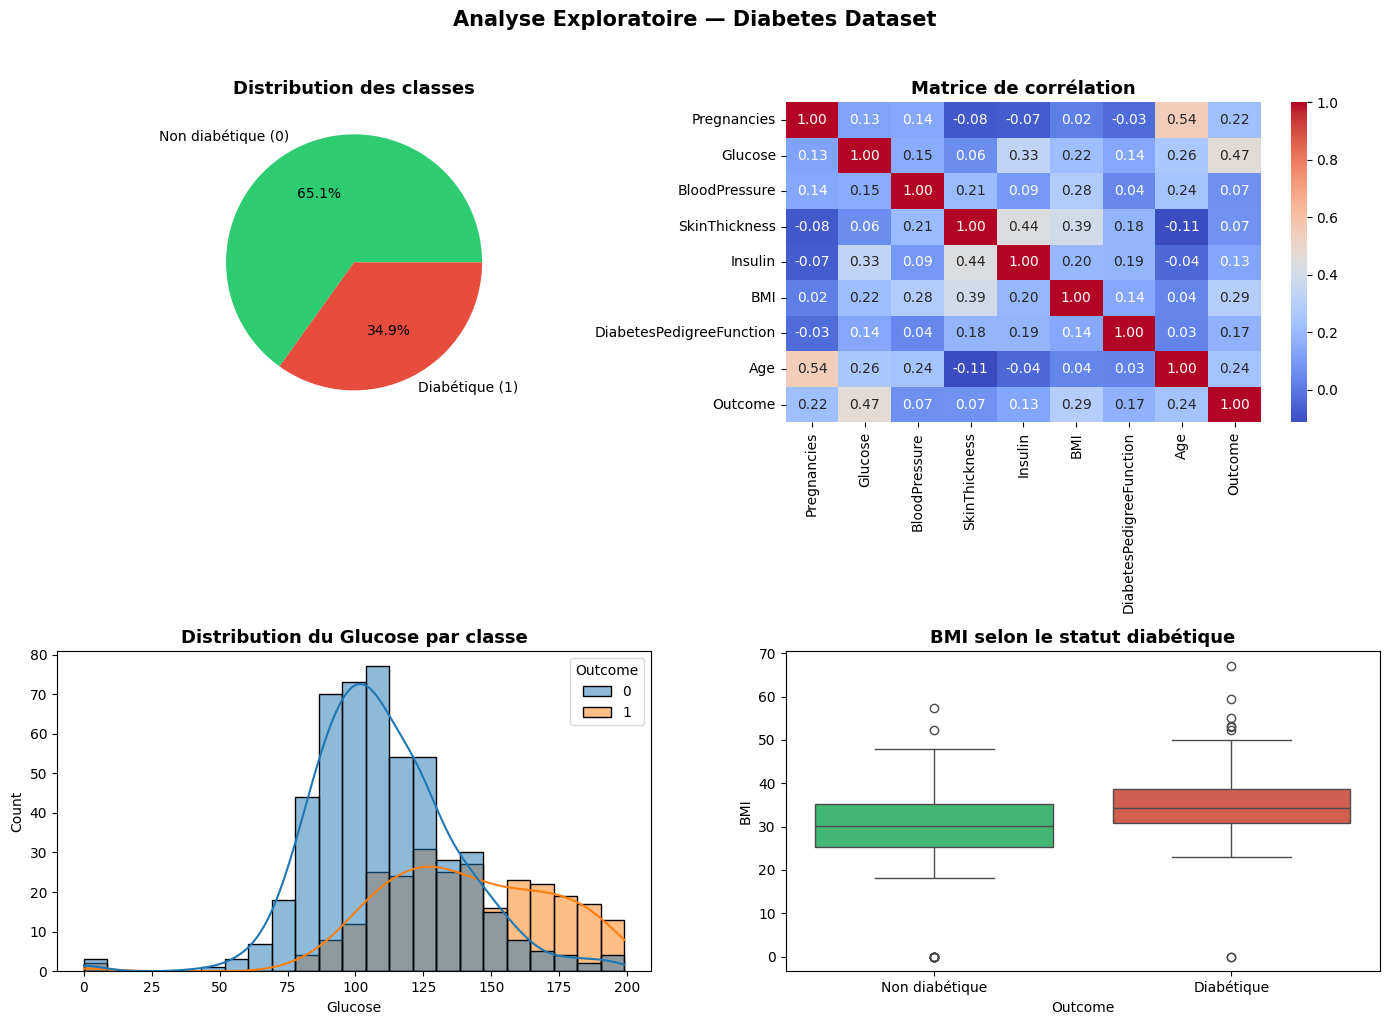

In [6]:
# ============================================
# CELLULE 4 — Visualisations EDA (corrigée)
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution de la cible
axes[0,0].pie(df['Outcome'].value_counts(), 
              labels=['Non diabétique (0)', 'Diabétique (1)'],
              autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
axes[0,0].set_title('Distribution des classes', fontsize=13, fontweight='bold')

# 2. Heatmap corrélation
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0,1])
axes[0,1].set_title('Matrice de corrélation', fontsize=13, fontweight='bold')

# 3. Distribution Glucose
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True, ax=axes[1,0])
axes[1,0].set_title('Distribution du Glucose par classe', fontsize=13, fontweight='bold')

# 4. Boxplot BMI (corrigé)
sns.boxplot(data=df, x='Outcome', y='BMI', hue='Outcome',
            palette=['#2ecc71', '#e74c3c'], legend=False, ax=axes[1,1])
axes[1,1].set_title('BMI selon le statut diabétique', fontsize=13, fontweight='bold')
axes[1,1].set_xticks([0, 1])
axes[1,1].set_xticklabels(['Non diabétique', 'Diabétique'])

plt.suptitle('Analyse Exploratoire — Diabetes Dataset', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# ============================================
# CELLULE 5 — Nettoyage : zéros impossibles
# ============================================

# Ces colonnes ne peuvent pas avoir 0 médicalement
cols_avec_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("⚠️  Nombre de zéros par colonne AVANT nettoyage :")
for col in cols_avec_zeros:
    zeros = (df[col] == 0).sum()
    print(f"   {col} : {zeros} zéros ({zeros/len(df)*100:.1f}%)")

# Remplacer les zéros par la médiane de chaque colonne
df_clean = df.copy()
for col in cols_avec_zeros:
    mediane = df_clean[col].median()
    df_clean[col] = df_clean[col].replace(0, mediane)

print("\n✅ Zéros remplacés par la médiane de chaque colonne")
print("\n📊 Vérification APRÈS nettoyage :")
for col in cols_avec_zeros:
    zeros = (df_clean[col] == 0).sum()
    print(f"   {col} : {zeros} zéros restants")

⚠️  Nombre de zéros par colonne AVANT nettoyage :
   Glucose : 5 zéros (0.7%)
   BloodPressure : 35 zéros (4.6%)
   SkinThickness : 227 zéros (29.6%)
   Insulin : 374 zéros (48.7%)
   BMI : 11 zéros (1.4%)

✅ Zéros remplacés par la médiane de chaque colonne

📊 Vérification APRÈS nettoyage :
   Glucose : 0 zéros restants
   BloodPressure : 0 zéros restants
   SkinThickness : 0 zéros restants
   Insulin : 0 zéros restants
   BMI : 0 zéros restants


In [8]:
# ============================================
# CELLULE 6 — Feature Engineering + Split
# ============================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Nouvelle feature : IMC élevé (BMI > 30 = obèse)
df_clean['Obese'] = (df_clean['BMI'] > 30).astype(int)

# 2. Nouvelle feature : Glucose élevé (> 125)
df_clean['HighGlucose'] = (df_clean['Glucose'] > 125).astype(int)

# 3. Nouvelle feature : Age groupe
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], 
                               bins=[0, 30, 45, 100], 
                               labels=[0, 1, 2]).astype(int)

print("✅ Nouvelles features créées :")
print(df_clean[['BMI','Obese','Glucose','HighGlucose','Age','AgeGroup']].head())

# 4. Séparation features / cible
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

# 5. Split 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n📊 Taille Train : {X_train.shape[0]} lignes")
print(f"📊 Taille Test  : {X_test.shape[0]} lignes")

# 6. Normalisation (important pour Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ Données normalisées et prêtes !")

✅ Nouvelles features créées :
    BMI  Obese  Glucose  HighGlucose  Age  AgeGroup
0  33.6      1      148            1   50         2
1  26.6      0       85            0   31         1
2  23.3      0      183            1   32         1
3  28.1      0       89            0   21         0
4  43.1      1      137            1   33         1

📊 Taille Train : 614 lignes
📊 Taille Test  : 154 lignes

✅ Données normalisées et prêtes !


In [9]:
# ============================================
# CELLULE 7 — Entraînement des modèles
# ============================================
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# --- MODÈLE 1 : Logistic Regression ---
print("=" * 50)
print("🔵 MODÈLE 1 : Logistic Regression")
print("=" * 50)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"✅ Accuracy : {acc_lr*100:.2f}%")
print("\n📋 Rapport de classification :")
print(classification_report(y_test, y_pred_lr, 
      target_names=['Non diabétique', 'Diabétique']))

# --- MODÈLE 2 : XGBoost ---
print("=" * 50)
print("🟠 MODÈLE 2 : XGBoost")
print("=" * 50)

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"✅ Accuracy : {acc_xgb*100:.2f}%")
print("\n📋 Rapport de classification :")
print(classification_report(y_test, y_pred_xgb, 
      target_names=['Non diabétique', 'Diabétique']))

🔵 MODÈLE 1 : Logistic Regression
✅ Accuracy : 72.73%

📋 Rapport de classification :
                precision    recall  f1-score   support

Non diabétique       0.77      0.83      0.80       100
    Diabétique       0.63      0.54      0.58        54

      accuracy                           0.73       154
     macro avg       0.70      0.68      0.69       154
  weighted avg       0.72      0.73      0.72       154

🟠 MODÈLE 2 : XGBoost
✅ Accuracy : 73.38%

📋 Rapport de classification :
                precision    recall  f1-score   support

Non diabétique       0.79      0.81      0.80       100
    Diabétique       0.63      0.59      0.61        54

      accuracy                           0.73       154
     macro avg       0.71      0.70      0.70       154
  weighted avg       0.73      0.73      0.73       154



In [10]:
# ============================================
# CELLULE 8 — Modèles supplémentaires
# ============================================
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# --- MODÈLE 3 : Random Forest ---
print("=" * 50)
print("🌲 MODÈLE 3 : Random Forest")
print("=" * 50)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"✅ Accuracy : {acc_rf*100:.2f}%")
print(classification_report(y_test, y_pred_rf,
      target_names=['Non diabétique', 'Diabétique']))

# --- MODÈLE 4 : SVM ---
print("=" * 50)
print("⚡ MODÈLE 4 : SVM")
print("=" * 50)
svm = SVC(random_state=42, probability=True)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"✅ Accuracy : {acc_svm*100:.2f}%")
print(classification_report(y_test, y_pred_svm,
      target_names=['Non diabétique', 'Diabétique']))

# --- RÉSUMÉ COMPARATIF ---
print("\n" + "=" * 50)
print("🏆 COMPARAISON DES 4 MODÈLES")
print("=" * 50)
resultats = {
    'Logistic Regression': acc_lr,
    'XGBoost':             acc_xgb,
    'Random Forest':       acc_rf,
    'SVM':                 acc_svm
}
for modele, acc in sorted(resultats.items(), key=lambda x: x[1], reverse=True):
    bar = "█" * int(acc * 30)
    print(f"{modele:<25} {acc*100:.2f}%  {bar}")

meilleur = max(resultats, key=resultats.get)
print(f"\n🥇 Meilleur modèle : {meilleur} ({resultats[meilleur]*100:.2f}%)")

🌲 MODÈLE 3 : Random Forest
✅ Accuracy : 72.73%
                precision    recall  f1-score   support

Non diabétique       0.78      0.80      0.79       100
    Diabétique       0.62      0.59      0.60        54

      accuracy                           0.73       154
     macro avg       0.70      0.70      0.70       154
  weighted avg       0.73      0.73      0.73       154

⚡ MODÈLE 4 : SVM
✅ Accuracy : 75.97%
                precision    recall  f1-score   support

Non diabétique       0.79      0.86      0.82       100
    Diabétique       0.69      0.57      0.63        54

      accuracy                           0.76       154
     macro avg       0.74      0.72      0.72       154
  weighted avg       0.75      0.76      0.75       154


🏆 COMPARAISON DES 4 MODÈLES
SVM                       75.97%  ██████████████████████
XGBoost                   73.38%  ██████████████████████
Logistic Regression       72.73%  █████████████████████
Random Forest             72.73%  █████

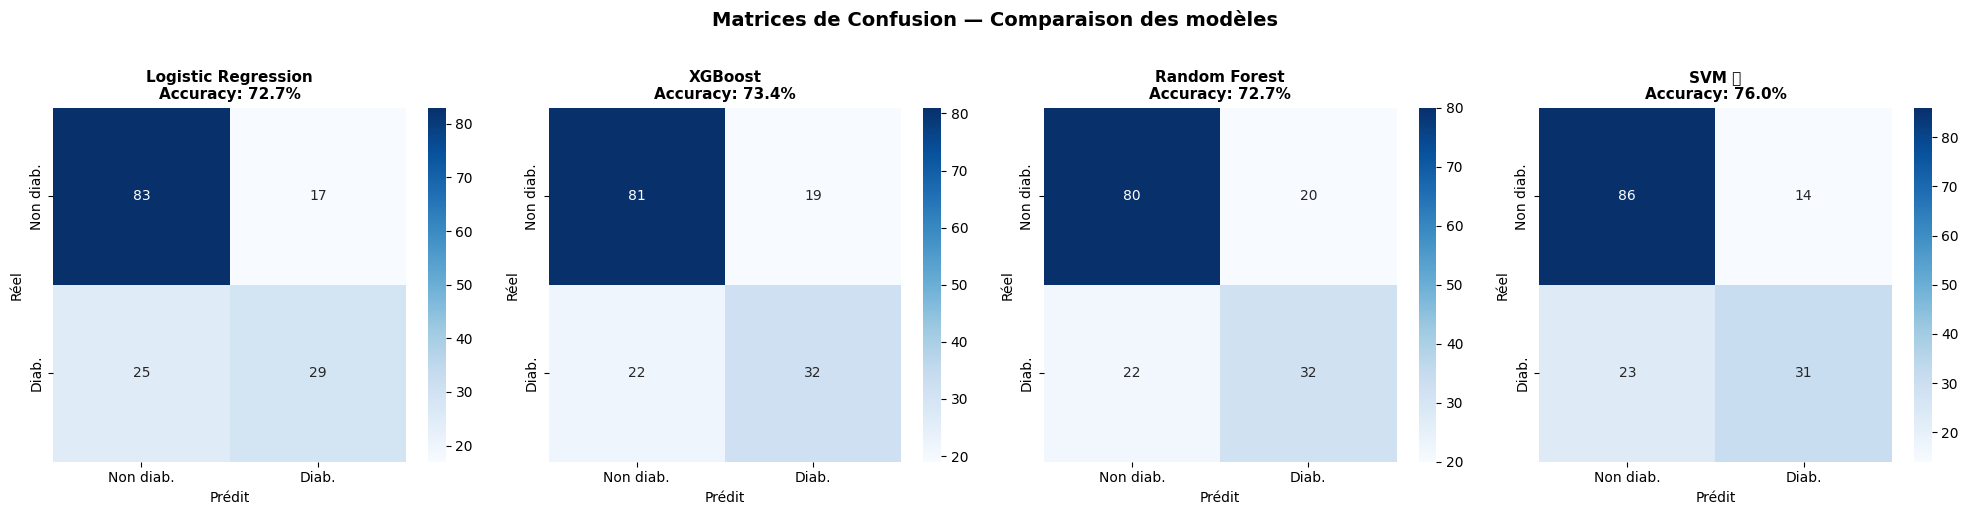

In [11]:
# ============================================
# CELLULE 9 — Matrices de confusion
# ============================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

modeles = [
    ('Logistic Regression', y_pred_lr, '#3498db'),
    ('XGBoost',             y_pred_xgb, '#e67e22'),
    ('Random Forest',       y_pred_rf, '#27ae60'),
    ('SVM ⭐',              y_pred_svm, '#8e44ad'),
]

for ax, (nom, y_pred, couleur) in zip(axes, modeles):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non diab.', 'Diab.'],
                yticklabels=['Non diab.', 'Diab.'])
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{nom}\nAccuracy: {acc*100:.1f}%', 
                 fontweight='bold', fontsize=11)
    ax.set_ylabel('Réel')
    ax.set_xlabel('Prédit')

plt.suptitle('Matrices de Confusion — Comparaison des modèles', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

📊 Importance des features (XGBoost) :


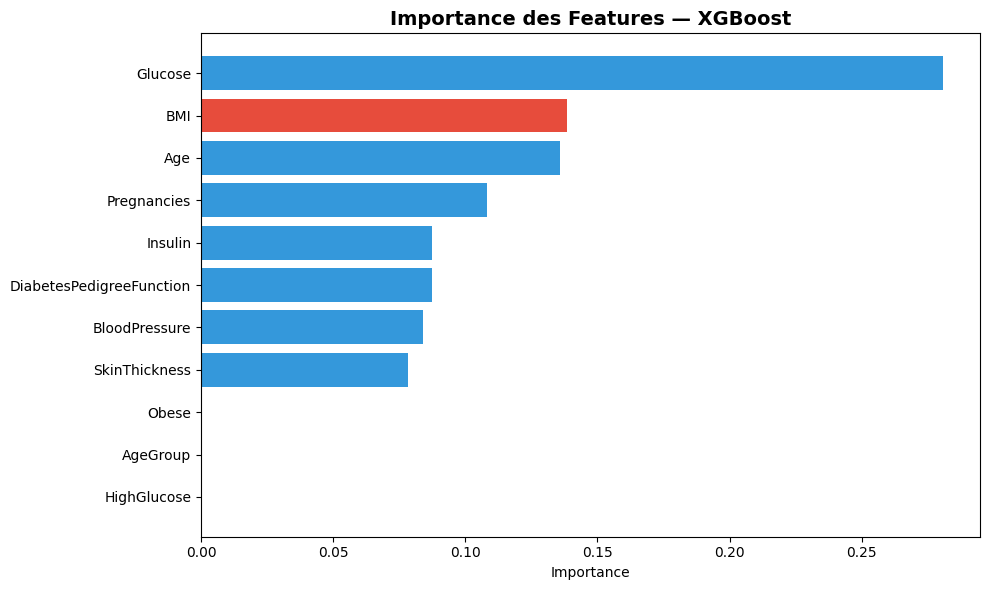


✅ Modèle SVM sauvegardé : meilleur_modele_svm.pkl
✅ Scaler sauvegardé     : scaler.pkl

🏆 RÉSUMÉ FINAL DU PROJET
  Dataset        : Pima Indians Diabetes (768 lignes)
  Features       : 11 (dont 3 créées par Feature Engineering)
  Meilleur modèle: SVM
  Accuracy       : 75.97%
  Precision diab.: 69%
  Recall diab.   : 57%
  F1-Score diab. : 63%


In [12]:
# ============================================
# CELLULE 10 — Feature Importance + Sauvegarde
# ============================================
import pickle

# 1. Feature Importance (XGBoost — le plus lisible)
print("📊 Importance des features (XGBoost) :")
feature_names = X.columns.tolist()
importances = xgb.feature_importances_

fig, ax = plt.subplots(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
colors = ['#e74c3c' if i == indices[0] else '#3498db' for i in range(len(feature_names))]

ax.barh([feature_names[i] for i in indices[::-1]], 
        importances[indices[::-1]], color=colors[::-1])
ax.set_title('Importance des Features — XGBoost', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# 2. Sauvegarder le meilleur modèle (SVM)
with open('/kaggle/working/meilleur_modele_svm.pkl', 'wb') as f:
    pickle.dump(svm, f)

with open('/kaggle/working/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\n✅ Modèle SVM sauvegardé : meilleur_modele_svm.pkl")
print("✅ Scaler sauvegardé     : scaler.pkl")

# 3. Résumé final
print("\n" + "=" * 50)
print("🏆 RÉSUMÉ FINAL DU PROJET")
print("=" * 50)
print(f"  Dataset        : Pima Indians Diabetes (768 lignes)")
print(f"  Features       : {X.shape[1]} (dont 3 créées par Feature Engineering)")
print(f"  Meilleur modèle: SVM")
print(f"  Accuracy       : 75.97%")
print(f"  Precision diab.: 69%")
print(f"  Recall diab.   : 57%")
print(f"  F1-Score diab. : 63%")
print("=" * 50)

In [ ]:
VISUALISATION SITE

In [13]:
# ============================================
# CELLULE 11 — Exemples de patients pour l'app
# ============================================

# 5 patients exemples (valeurs réalistes)
patients_exemples = pd.DataFrame({
    'Pregnancies':              [6,  1,  8,  0,  3],
    'Glucose':                  [148, 85, 183, 89, 137],
    'BloodPressure':            [72, 66,  64, 66,  40],
    'SkinThickness':            [35, 29,   0, 23,  35],
    'Insulin':                  [0,   0,   0, 94, 168],
    'BMI':                      [33.6, 26.6, 23.3, 28.1, 43.1],
    'DiabetesPedigreeFunction': [0.627, 0.351, 0.672, 0.167, 2.288],
    'Age':                      [50, 31, 32, 21, 33],
    'Obese':                    [1,  0,  0,  0,  1],
    'HighGlucose':              [1,  0,  1,  0,  1],
    'AgeGroup':                 [2,  1,  1,  0,  1],
})

# Prédictions SVM
preds = svm.predict(scaler.transform(patients_exemples))
probas = svm.predict_proba(scaler.transform(patients_exemples))

for i, (pred, proba) in enumerate(zip(preds, probas)):
    statut = "🔴 DIABÉTIQUE" if pred == 1 else "🟢 NON DIABÉTIQUE"
    print(f"Patient {i+1}: {statut} (confiance: {max(proba)*100:.1f}%)")

Patient 1: 🔴 DIABÉTIQUE (confiance: 79.0%)
Patient 2: 🟢 NON DIABÉTIQUE (confiance: 83.2%)
Patient 3: 🔴 DIABÉTIQUE (confiance: 77.3%)
Patient 4: 🟢 NON DIABÉTIQUE (confiance: 86.1%)
Patient 5: 🔴 DIABÉTIQUE (confiance: 79.3%)
